# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load and Inspect Dataset

In [2]:
df = pd.read_csv(
    "HBSC_data/HBSC2018OAed1.1.csv",
    sep=";",
    engine="python"
)
# Inspect age column
print(sorted(df["age"].dropna().unique()))

# Filter to target age range
df["age"] = (
    df["age"]
    .astype(str)
    .str.replace(",", ".", regex=False) # ensure that ages like 15,6 get converted to 15.6
)

df["age"] = pd.to_numeric(df["age"], errors="coerce")

df = df[(df["age"] >= 13) & (df["age"] <= 16.5)].copy()

print("Filtered dataset shape (age 13 to 16.5):", df.shape)
display(df.head())

# get column names from the dataframe
cols = df.columns.tolist()

pd.set_option('display.max_columns', None)

[' ', '10', '10,5', '10,5833333333333', '10,5833333333335', '10,6666666666665', '10,6666666666667', '10,75', '10,8333333333333', '10,8333333333335', '10,9166666666665', '10,9166666666667', '11', '11,0833333333333', '11,0833333333335', '11,1666666666665', '11,1666666666667', '11,25', '11,3333333333333', '11,3333333333335', '11,4166666666665', '11,4166666666667', '11,5', '11,5833333333333', '11,5833333333335', '11,6666666666665', '11,6666666666667', '11,75', '11,8333333333333', '11,8333333333335', '11,9166666666665', '11,9166666666667', '12', '12,0833333333333', '12,0833333333335', '12,1666666666665', '12,1666666666667', '12,25', '12,3333333333333', '12,3333333333335', '12,4166666666665', '12,4166666666667', '12,5', '12,5833333333333', '12,5833333333335', '12,6666666666665', '12,6666666666667', '12,75', '12,8333333333333', '12,8333333333335', '12,9166666666665', '12,9166666666667', '13', '13,0833333333333', '13,0833333333335', '13,1666666666665', '13,1666666666667', '13,25', '13,33333333

,HBSC,seqno_int,cluster,countryno,region,id1,id2,id3,id4,weight,...,talkstepmo,famhelp,famsup,famtalk,famdec,MBMI,IRFAS,IRRELFAS_LMH,IOTF4,oweight_who
43390,2018,102603,100040,8000,AL,2,12,40,489,1,...,,,,,,"16,796875",,,2,0
43391,2018,102605,100005,8000,AL,1,3,5,960,1,...,5,,,,,,,,,
43392,2018,102981,100184,8000,AL,8,46,184,99,1,...,5,7,7,6,6,"17,6897888516692",7,2,2,0
43393,2018,102985,100025,8000,AL,2,8,25,659,1,...,5,7,7,7,7,16,10,3,2,0
43394,2018,102986,100026,8000,AL,2,8,26,660,1,...,5,7,7,7,7,"17,7777777777778",3,1,2,0


# Map column names to their descriptions

In [3]:
# Item labels (from HBSC codebook variable titles)
labels = {
    'HBSC':'HBSC round',
    'seqno_int':'Identify each row in cross national files',
    'cluster':'Identify each class or cluster in cross national files',
    'countryno':'Country/WHO region',
    'region':'HBSC region',
    'id1':'Region/municipality',
    'id2':'School',
    'id3':'Class',
    'id4':'Pupil no.',
    'weight':'Weight of dataset',
    'adm':'Mode of quest. adm.',
    'month':'Month of data collection',
    'year':'Year of data collection',
    'age':'Age',
    'agecat':'Age category',
    'sex':'Gender',
    'grade':'Grade',
    'monthbirth':'Month of birth',
    'yearbirth':'Year of birth',
    'fasfamcar':'Family car',
    'fasbedroom':'Own bedroom',
    'fascomputers':'No. of computers',
    'fasbathroom':'No. of bathrooms',
    'fasdishwash':'Dishwasher in home',
    'fasholidays':'Family holidays',
    'health':'Health',
    'lifesat':'Life satisfaction',
    'headache':'Headache',
    'stomachache':'Stomach ache',
    'backache':'Back ache',
    'feellow':'Feeling low',
    'irritable':'Irritability or bad temper',
    'nervous':'Feeling nervous',
    'sleepdificulty':'Difficulties in sleeping',
    'dizzy':'Feeling dizzy',
    'thinkbody':'Think about body',
    'physact60':'Physical activity past 7 days',
    'breakfastwd':'Breakfast weekdays',
    'breakfastwe':'Breakfast weekends',
    'fruits_2':'Eat fruits',
    'vegetables_2':'Eat vegetables',
    'sweets_2':'Eat sweets',
    'softdrinks_2':'Drink coke/soft drinks',
    'fmeal':'Family meals together',
    'toothbr':'Tooth brushing',
    'timeexe':'Vigorous physical activity frequency',
    'smokltm':'Days smoked in lifetime',
    'smok30d_2':'Days smoked last 30 days',
    'alcltm':'Alcohol use in lifetime',
    'alc30d_2':'Alcohol use last 30 days',
    'drunkltm':'Drunkenness lifetime',
    'drunk30d':'Drunkenness last 30 days',
    'cannabisltm_2':'Cannabis life time',
    'cannabis30d_2':'Cannabis last 30 days',
    'bodyweight':'Weight - Kilo',
    'bodyheight':'Height - Centimetre',
    'likeschool':'Liking school',
    'schoolpressure':'Pressured by schoolwork',
    'studtogether':'Students enjoy being together',
    'studhelpful':'Students kind and helpful',
    'studaccept':'Students accept me',
    'teacheraccept':'Teacher accepts me',
    'teachercare':'Teacher cares about me',
    'teachertrust':'Feel trust in teacher',
    'bulliedothers':'Bullying others',
    'beenbullied':'Been bullied past months',
    'cbulliedothers':'Cyber bullied others',
    'cbeenbullied':'Been cyber bullied',
    'fight12m':'Times physical fight',
    'injured12m':'Times injured',
    'friendhelp':'Friends try to help',
    'friendcounton':'Can count on friends',
    'friendshare':'Friends to share joys with',
    'friendtalk':'Can talk about problems with friends',
    'emconlfreq1':'Onl contact close friends',
    'emconlfreq2':'Onl contact larger friend group',
    'emconlfreq3':'Onl contact online friends',
    'emconlfreq4':'Onl contact other',
    'emconlpref1':'Secrets, more easily online',
    'emconlpref2':'Feelings, more easily online',
    'emconlpref3':'Concerns, more easily online',
    'emcsocmed1':"Social media: Can't think of anything else",
    'emcsocmed2':'Social media: Spend more time',
    'emcsocmed3':'Social media: Felt bad',
    'emcsocmed4':'Social media: Failed to spend less time',
    'emcsocmed5':'Social media: Neglected other activities',
    'emcsocmed6':'Social media: Arguments because of use',
    'emcsocmed7':'Social media: Lied about amount',
    'emcsocmed8':'Social media: Escape from negative feelings',
    'emcsocmed9':'Social media: Conflict with family because of use',
    'hadsex':'Sexual intercourse',
    'agesex':'Age when first sexual intercourse',
    'contraceptcondom':'Contraceptive-condoms',
    'contraceptpill':'Contraceptive-birth control pills',
    'countryborn':'Country of birth - ISO 3166',
    'countrybornmo':"Mother's country of birth - ISO 3166",
    'countrybornfa':"Father's country of birth - ISO 3166",
    'motherhome1':'Mother in main home',
    'fatherhome1':'Father in main home',
    'stepmohome1':'Stepmother in main home',
    'stepfahome1':'Stepfather in main home',
    'fosterhome1':'Living in foster/child home',
    'elsehome1_2':'Living with someone else or somewhere else',
    'employfa':'Father job',
    'employmo':'Mother job',
    'employnotfa':'Father not job',
    'employnotmo':'Mother not job',
    'talkfather':'Talk to father',
    'talkstepfa':'Talk to stepfather',
    'talkmother':'Talk to mother',
    'talkstepmo':'Talk to stepmother',
    'famhelp':'Family tries to help',
    'famsup':'Get emotional help',
    'famtalk':'Talk about problems',
    'famdec':'Help make decisions',
    'MBMI':'Body Mass Index',
    'IRFAS':'Family affluence scale III  -  continuous',
    'IRRELFAS_LMH':'Relative family affluence categorical',
    'IOTF4':'IOTF 4 classes',
    'oweight_who':'Classified as overweight or obese by WHO (bmiplus1=1)'
}

def stem(c):
    if c in ['headache','stomachache','backache','feellow','irritable','nervous','sleepdificulty','dizzy']:
        return 'In the last 6 months: how often have you had the following? Please tick one box for each line.'
    if c == 'health':
        return 'Would you say your health is…?'
    if c == 'lifesat':
        return 'Here is a picture of a ladder. The top of the ladder (10) is the best possible life for you and the bottom (0) is the worst possible life for you. Where on the ladder do you feel you stand at the moment?'
    if c == 'physact60':
        return 'Over the past 7 days, on how many days were you physically active for a total of at least 60 minutes per day?'
    if c in ['breakfastwd','breakfastwe']:
        return 'How often do you usually have breakfast (more than a glass of milk or fruit juice)? Please tick one box for weekdays and one box for weekend.'
    if c in ['fruits_2','vegetables_2','sweets_2','softdrinks_2']:
        return 'How many times a week do you usually eat/drink the following food or drinks?'
    if c == 'fmeal':
        return 'How often do you usually have meals together with your family?'
    if c == 'toothbr':
        return 'How often do you brush your teeth?'
    if c == 'timeexe':
        return 'Outside school hours: how often do you usually exercise in your free time so much that you get out of breath or sweat?'
    if c in ['smokltm','alcltm','drunkltm','cannabisltm_2']:
        return 'Lifetime use question (ever in your life).'
    if c in ['smok30d_2','alc30d_2','drunk30d','cannabis30d_2']:
        return 'Use frequency in the last 30 days.'
    if c == 'likeschool':
        return 'How do you feel about school at present?'
    if c == 'schoolpressure':
        return 'How pressured do you feel by the schoolwork you have to do?'
    if c in ['studtogether','studhelpful','studaccept']:
        return 'Here are some statements about the students in your class(es). Please show how much you agree or disagree with each one. Please tick one box for each line.'
    if c in ['teacheraccept','teachercare','teachertrust']:
        return 'Here are some statements about your teachers. Please show how much you agree or disagree with each one. Please tick one box for each line.'
    if c in ['bulliedothers','beenbullied','cbulliedothers','cbeenbullied']:
        return 'Here are some questions about bullying/cyberbullying. A person is bullied when another person or group repeatedly says or does nasty and unpleasant things to them.'
    if c in ['fight12m','injured12m']:
        return 'In the past 12 months…'
    if c in ['friendhelp','friendcounton','friendshare','friendtalk','famhelp','famsup','famtalk','famdec']:
        return 'We are interested in how you feel about the following statements. Please show how much you agree or disagree with each one. Please tick one box for each line.'
    if c in ['talkfather','talkstepfa','talkmother','talkstepmo']:
        return 'How easy is it for you to talk to the following persons about things that really bother you? Please tick one box for each line.'
    if c.startswith('emconlfreq'):
        return 'How often do you have online contact with the following people/groups?'
    if c.startswith('emconlpref'):
        return 'Compared with face-to-face communication, how easy is it to discuss the following online?'
    if c.startswith('emcsocmed'):
        return 'In the last year, how often have these experiences happened because of social media use?'
    if c == 'hadsex':
        return 'Have you ever had sexual intercourse (sometimes this is called “making love”, “having sex”, or “going all the way”)?'
    if c == 'agesex':
        return 'How old were you when you had sexual intercourse for the first time?'
    if c in ['contraceptcondom','contraceptpill']:
        return 'The last time you had sexual intercourse, did you or your partner use any of the following methods?'
    if c.startswith('fas') or c in ['IRFAS','IRRELFAS_LMH']:
        return 'Family Affluence Scale (material assets at home) items.'
    if c in ['bodyweight','bodyheight','MBMI','IOTF4','oweight_who']:
        return 'Anthropometric measure / derived BMI classification.'
    if c in ['countryborn','countrybornmo','countrybornfa']:
        return 'Country of birth question (self/mother/father).'
    if c.endswith('home1') or c == 'elsehome1_2':
        return 'Who lives in your main home?'
    if c in ['employfa','employmo','employnotfa','employnotmo']:
        return 'Parental employment status question.'
    if c == 'thinkbody':
        return 'Body image / perception item (see exact wording in codebook block).'
    return 'Administrative/derived variable (not a direct student item).'

mapping = pd.DataFrame({
    "column": cols,
    "full_question_stem": [stem(c) for c in cols],
    "item_text": [labels.get(c, "No label found") for c in cols]
})

#mapping.to_csv("HBSC_data/hbsc_column_question_mapping.csv", index=False)

display(mapping.head(20))

,column,full_question_stem,item_text
0,HBSC,Administrative/derived variable (not a direct ...,HBSC round
1,seqno_int,Administrative/derived variable (not a direct ...,Identify each row in cross national files
2,cluster,Administrative/derived variable (not a direct ...,Identify each class or cluster in cross nation...
3,countryno,Administrative/derived variable (not a direct ...,Country/WHO region
4,region,Administrative/derived variable (not a direct ...,HBSC region
5,id1,Administrative/derived variable (not a direct ...,Region/municipality
6,id2,Administrative/derived variable (not a direct ...,School
7,id3,Administrative/derived variable (not a direct ...,Class
8,id4,Administrative/derived variable (not a direct ...,Pupil no.
9,weight,Administrative/derived variable (not a direct ...,Weight of dataset


In [4]:
# Inspect datatype for each column
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 156603 entries, 43390 to 244096
Data columns (total 120 columns):
 #    Column            Dtype  
---   ------            -----  
 0    HBSC              int64  
 1    seqno_int         int64  
 2    cluster           int64  
 3    countryno         int64  
 4    region            object 
 5    id1               int64  
 6    id2               int64  
 7    id3               object 
 8    id4               int64  
 9    weight            object 
 10   adm               int64  
 11   month             object 
 12   year              int64  
 13   age               float64
 14   agecat            object 
 15   sex               int64  
 16   grade             object 
 17   monthbirth        object 
 18   yearbirth         object 
 19   fasfamcar         object 
 20   fasbedroom        object 
 21   fascomputers      object 
 22   fasbathroom       object 
 23   fasdishwash       object 
 24   fasholidays       object 
 25   health            o

# Distribution of responses by country


Percentage of responses from each country:


,country,count,percent
0,Wales,10169,6.493490
1,Canada,8930,5.702317
2,Czech Republic,7348,4.692120
3,France,5813,3.711934
4,Israel,5351,3.416920
5,Switzerland,4880,3.116160
6,Iceland,4664,2.978232
7,Ukraine,4292,2.740688
8,Slovenia,3700,2.362662
9,Croatia,3587,2.290505


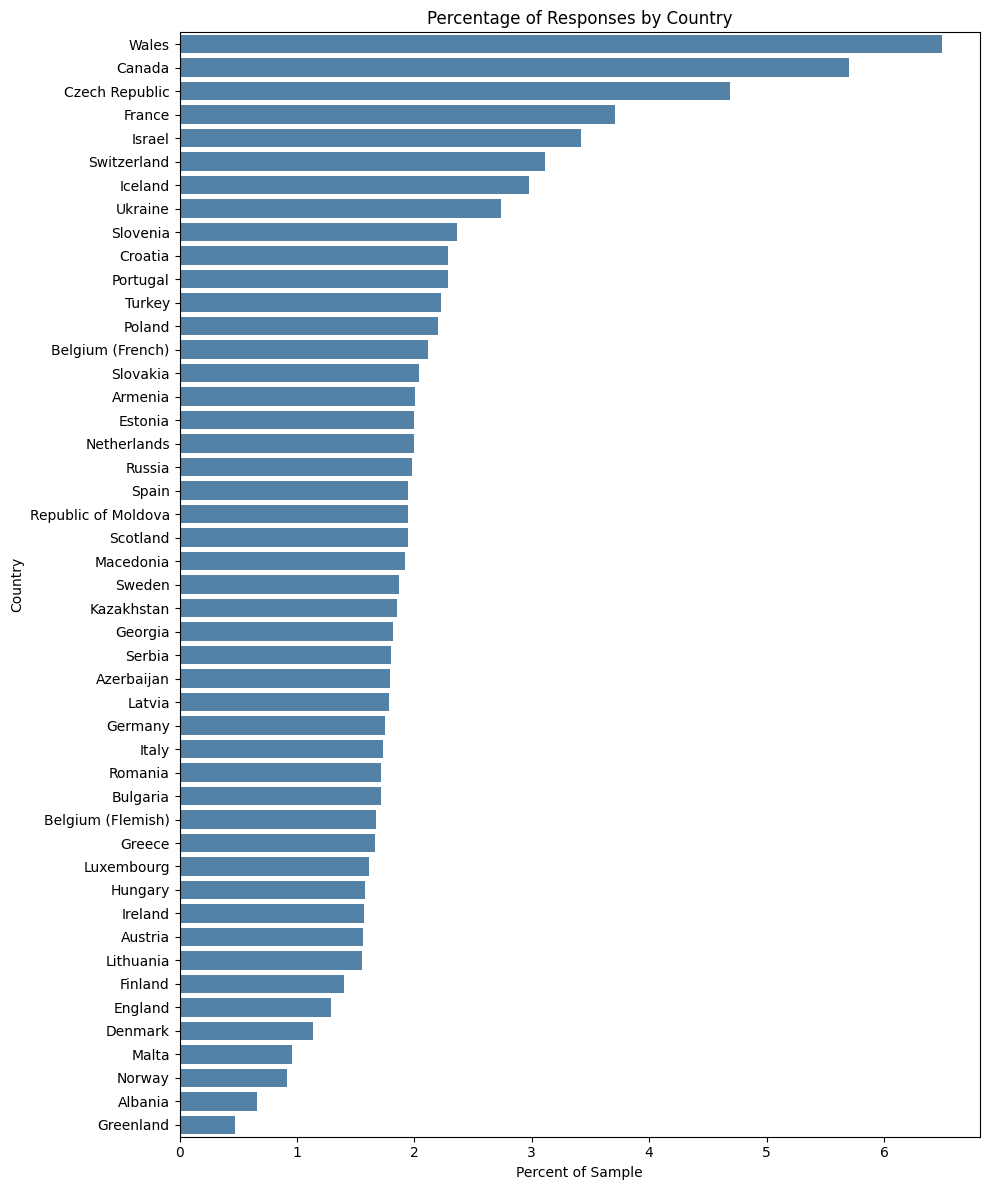

In [5]:
# Country mapping
country_map = {
    8000:"Albania",31000:"Azerbaijan",40000:"Austria",51000:"Armenia",
    56001:"Belgium (Flemish)",56002:"Belgium (French)",100000:"Bulgaria",
    124000:"Canada",191000:"Croatia",203000:"Czech Republic",208000:"Denmark",
    233000:"Estonia",246000:"Finland",250000:"France",268000:"Georgia",
    276000:"Germany",300000:"Greece",304000:"Greenland",348000:"Hungary",
    352000:"Iceland",372000:"Ireland",376000:"Israel",380000:"Italy",
    398000:"Kazakhstan",428000:"Latvia",440000:"Lithuania",442000:"Luxembourg",
    470000:"Malta",498000:"Republic of Moldova",528000:"Netherlands",
    578000:"Norway",616000:"Poland",620000:"Portugal",642000:"Romania",
    643000:"Russia",688000:"Serbia",703000:"Slovakia",705000:"Slovenia",
    724000:"Spain",752000:"Sweden",756000:"Switzerland",792000:"Turkey",
    804000:"Ukraine",807000:"Macedonia",826001:"England",826002:"Scotland",
    826003:"Wales",826004:"Northern Ireland",840000:"USA"
}

df["countryno"] = pd.to_numeric(df["countryno"], errors="coerce")

country_counts = (
    df["countryno"]
    .value_counts(dropna=False)
    .rename_axis("countryno")
    .reset_index(name="count")
)

country_counts["percent"] = country_counts["count"] / len(df) * 100

# Map to country names
country_counts["country"] = country_counts["countryno"].map(country_map)

# Sort descending for clean visual
country_counts = country_counts.sort_values("percent", ascending=False)

print("\nPercentage of responses from each country:")
display(country_counts[["country","count","percent"]])

# Plot (horizontal = no overlap issues)
plt.figure(figsize=(10, 12))

sns.barplot(
    data=country_counts,
    x="percent",
    y="country",
    color="steelblue"
)

plt.title("Percentage of Responses by Country")
plt.xlabel("Percent of Sample")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

# Choose pyschosomatic variables (Y variables) to compute Distress Score

In [6]:
y_vars = [
    "feellow",     # feeling low 
    "irritable",   # irritability / mood instability
    "nervous",     # anxiety
    "lifesat"      # life satisfaction 
]

# Plot distribution of responses for each Y variable


 feellow

 irritable

 nervous

 lifesat


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


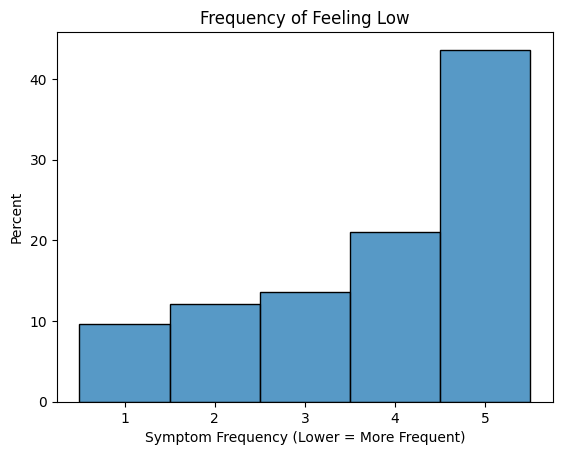

feellow
1.0    14753
2.0    18562
3.0    20944
4.0    32260
5.0    66927
NaN     3157
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


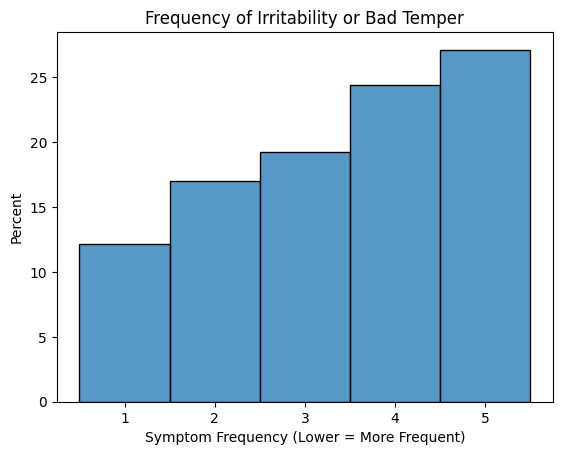

irritable
1.0    18708
2.0    26086
3.0    29604
4.0    37487
5.0    41677
NaN     3041
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


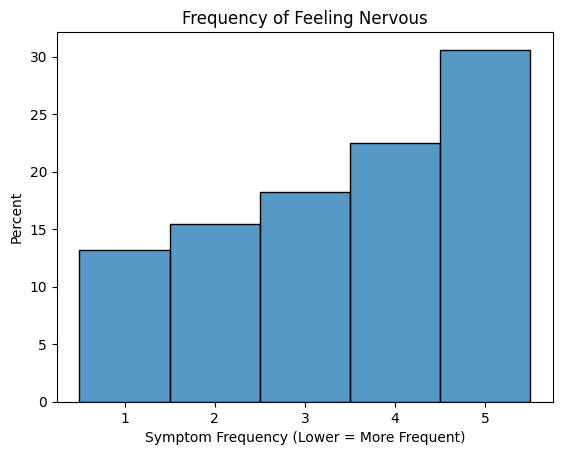

nervous
1.0    20299
2.0    23777
3.0    27949
4.0    34555
5.0    46970
NaN     3053
Name: count, dtype: int64


In [7]:
df[y_vars] = df[y_vars].apply(pd.to_numeric, errors="coerce")
for col in y_vars:
    print("\n", col)
    
likert_bins = [0.5,1.5,2.5,3.5,4.5,5.5]

question_titles = {
    "feellow": "Frequency of Feeling Low",
    "irritable": "Frequency of Irritability or Bad Temper",
    "nervous": "Frequency of Feeling Nervous"
}

for col in ["feellow","irritable","nervous"]:
    sns.histplot(
        df[col],
        bins=likert_bins,
        stat="percent"
    )
    plt.title(question_titles[col])
    plt.xlabel("Symptom Frequency (Lower = More Frequent)")
    plt.ylabel("Percent")
    plt.xticks([1,2,3,4,5])
    plt.show()
    print(df[col].value_counts(dropna=False).sort_index())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


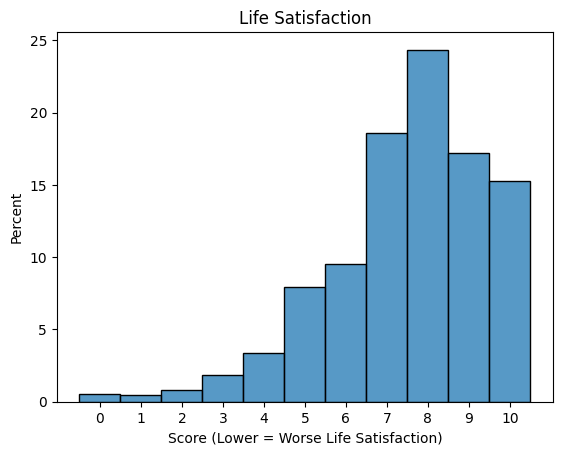

In [8]:
lifesat_bins = [-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5]

sns.histplot(
    df["lifesat"],
    bins=lifesat_bins,
    stat="percent"
)

plt.title("Life Satisfaction")
plt.xlabel("Score (Lower = Worse Life Satisfaction)")
plt.ylabel("Percent")
plt.xticks(range(0,11))
plt.show()

# Reverse the scales so that higher values indicate more distress

In [9]:
# reverse y vars so that higher value = higher distress
df["feellow_rev"] = 6 - df["feellow"]
df["irritable_rev"] = 6 - df["irritable"]
df["nervous_rev"] = 6 - df["nervous"]
df["lifesat_rev"] = 10 - df["lifesat"]

In [10]:
reversed_y_vars = [
    "feellow_rev",
    "irritable_rev",
    "nervous_rev",
    "lifesat_rev"
]

In [11]:
# Measure correlation between reversed y variables to confirm they measure a common distress dimension
df[reversed_y_vars].corr()

,feellow_rev,irritable_rev,nervous_rev,lifesat_rev
feellow_rev,1.000000,0.559806,0.502290,0.413477
irritable_rev,0.559806,1.000000,0.545116,0.327334
nervous_rev,0.502290,0.545116,1.000000,0.293898
lifesat_rev,0.413477,0.327334,0.293898,1.000000


In [12]:
# Drop all rows with any missing values in the y variables
df_y = df.dropna(subset=y_vars).copy()

print("Original sample size:", len(df))
print("Sample size after dropping NA in Y variables:", len(df_y))

removed = len(df) - len(df_y)
print("Percentage removed:", round(removed / len(df) * 100, 2), "%")

Original sample size: 156603
Sample size after dropping NA in Y variables: 150867
Percentage removed: 3.66 %


# Cronbach's alpha

In [13]:
# Compute Cronbach's alpha to measure their internal consistency and reliability as proxies for distress
items = df_y[reversed_y_vars]

k = items.shape[1]

item_variances = items.var(axis=0, ddof=1)

total_score = items.sum(axis=1)

total_variance = total_score.var(ddof=1)

cronbach_alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

print("Cronbach's alpha:", round(cronbach_alpha, 3))

Cronbach's alpha: 0.737


The psychosomatic symptom items demonstrate good internal consistency (Cronbach’s α = 0.737), supporting the use of their average as a composite distress score.

In [14]:
# Standardise scales of reversed y variables so lifesat_rev (larger scale) doesnt dominate
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

z_vars = [v + "_z" for v in reversed_y_vars]

df_y[z_vars] = scaler.fit_transform(df_y[reversed_y_vars])
df_y["distress_score_z"] = df_y[z_vars].mean(axis=1)

# Convert distress score to 0-100 scale

In [15]:
# Convert to to 0-100 scale for dashboard ONLY
min_score = df_y["distress_score_z"].min()
max_score = df_y["distress_score_z"].max()

df_y["distress_score_100"] = (
    (df_y["distress_score_z"] - min_score) /
    (max_score - min_score)
) * 100

# EDA: Rank countries by Distress Score


Countries ranked by mean distress score:


,country,mean,median,count
41,Turkey,51.525101,54.451492,3262
22,Italy,41.565211,42.375274,2679
27,Malta,39.726136,37.313422,1422
16,Greece,39.694238,38.706834,2573
31,Poland,38.169585,35.614928,3367
39,Sweden,37.453935,35.089457,2761
21,Israel,37.318632,35.055631,5351
44,England,36.420235,33.601080,1954
18,Hungary,35.326740,32.285720,2408
42,Ukraine,34.941637,32.268807,4068


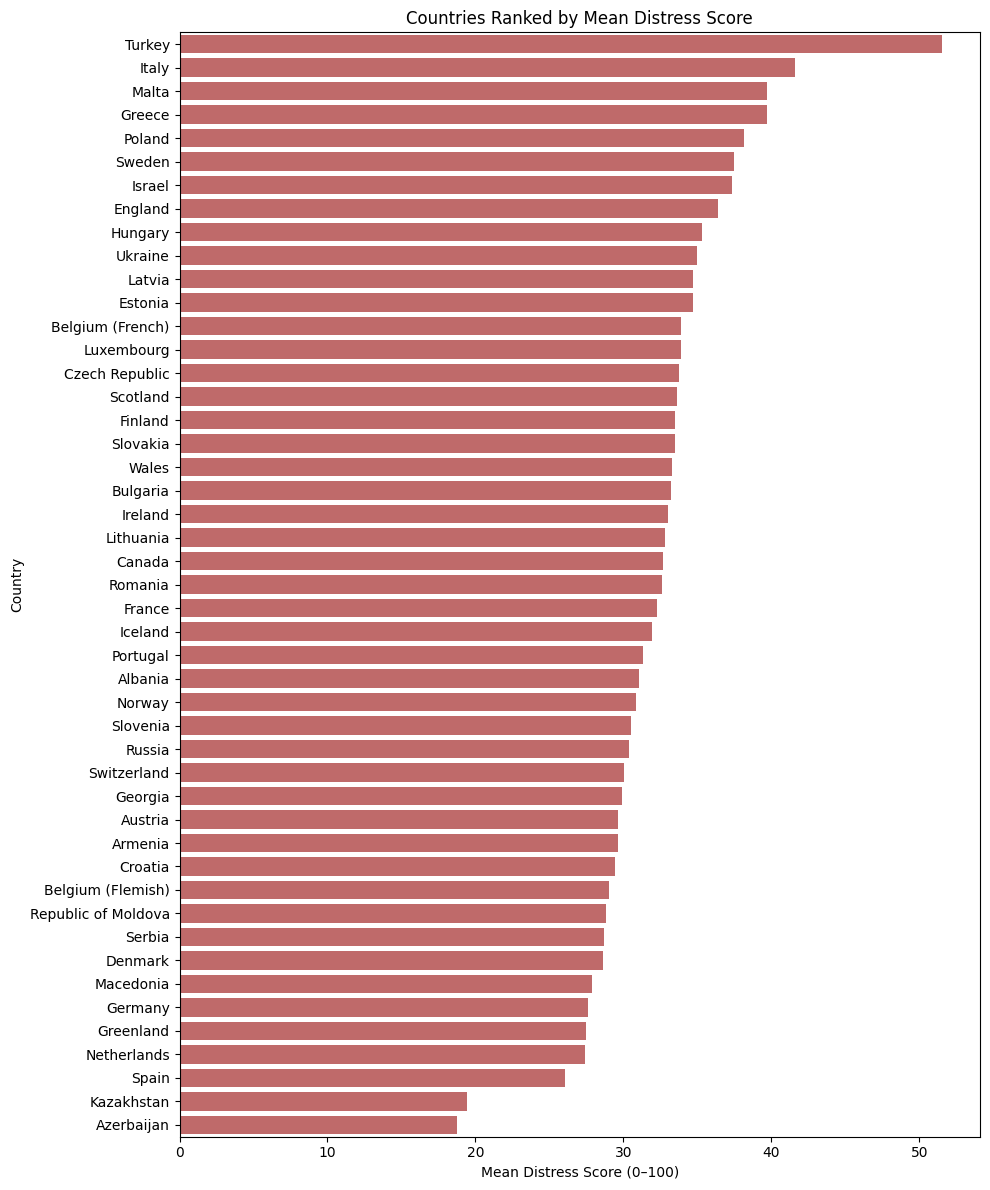

In [16]:
country_distress = (
    df_y.groupby("countryno", dropna=False)["distress_score_100"]
    .agg(["mean","median","count"])
    .reset_index()
)

# Map names
country_distress["country"] = country_distress["countryno"].map(country_map)

# Keep only countries with sufficient sample size
country_distress = country_distress[country_distress["count"] >= 100]

# Sort by distress
country_distress = country_distress.sort_values("mean", ascending=False)

print("\nCountries ranked by mean distress score:")
display(country_distress[["country","mean","median","count"]])

# Horizontal bar plot
plt.figure(figsize=(10, 12))

sns.barplot(
    data=country_distress,
    x="mean",
    y="country",
    color="indianred"
)

plt.title("Countries Ranked by Mean Distress Score")
plt.xlabel("Mean Distress Score (0–100)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

# EDA: Relationship between Age and Distress Score

/var/folders/6w/v4mx5hzn5z35dk5rqf7nc9nh0000gn/T/ipykernel_24590/786033673.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_y.groupby("age_bin")["distress_score_100"]
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


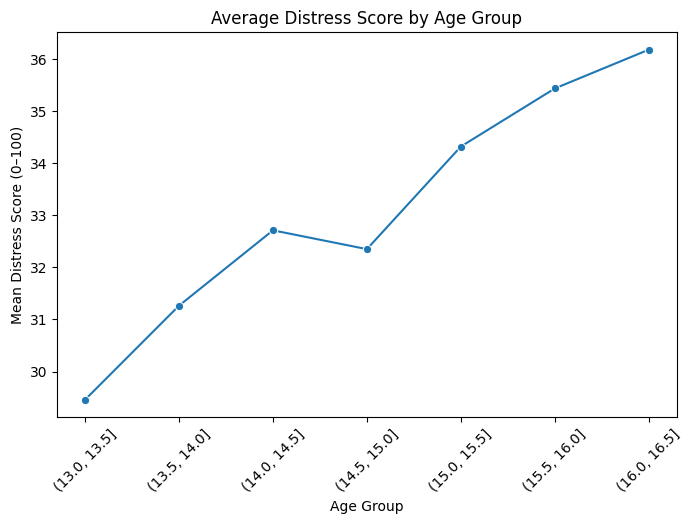

In [17]:
# Age bins (0.5 intervals)
df_y["age_bin"] = pd.cut(
    df_y["age"],
    bins=np.arange(13, 16.6, 0.5)
)

age_bin_mean = (
    df_y.groupby("age_bin")["distress_score_100"]
    .mean()
    .reset_index()
)

# Convert bin labels to string for plotting
age_bin_mean["age_bin"] = age_bin_mean["age_bin"].astype(str)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=age_bin_mean,
    x="age_bin",
    y="distress_score_100",
    marker="o"
)

plt.title("Average Distress Score by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Distress Score (0–100)")

plt.xticks(rotation=45)
plt.show()

In [18]:
# Divide into quantiles for risk tier assignment
p70 = df_y["distress_score_100"].quantile(0.70)
p85 = df_y["distress_score_100"].quantile(0.85)
p95 = df_y["distress_score_100"].quantile(0.95)

print("70th percentile:", round(p70,2))
print("85th percentile:", round(p85,2))
print("95th percentile:", round(p95,2))

70th percentile: 42.56
85th percentile: 58.07
95th percentile: 73.85


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


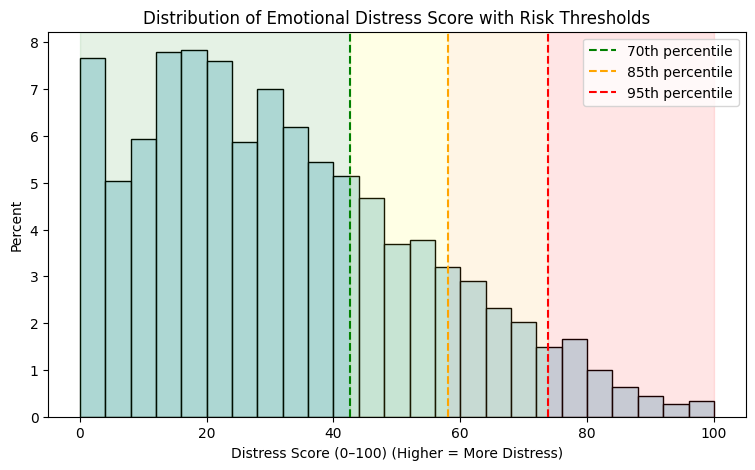

In [19]:
# Plot distress score distribution with risk thresholds
plt.figure(figsize=(9,5))

sns.histplot(
    df_y["distress_score_100"],
    bins=25,
    stat="percent",
    color="lightblue",
    edgecolor="black"
)

# Percentile cutoffs
plt.axvline(p70, color="green", linestyle="--", label="70th percentile")
plt.axvline(p85, color="orange", linestyle="--", label="85th percentile")
plt.axvline(p95, color="red", linestyle="--", label="95th percentile")

plt.title("Distribution of Emotional Distress Score with Risk Thresholds")
plt.xlabel("Distress Score (0–100) (Higher = More Distress)")
plt.ylabel("Percent")

plt.legend()
plt.axvspan(0, p70, color="green", alpha=0.1)
plt.axvspan(p70, p85, color="yellow", alpha=0.1)
plt.axvspan(p85, p95, color="orange", alpha=0.1)
plt.axvspan(p95, 100, color="red", alpha=0.1)

plt.show()

In [20]:
# Assign risk tiers
def assign_risk(score):
    if score < p70:
        return "Low"
    elif score < p85:
        return "Moderate"
    elif score < p95:
        return "High"
    else:
        return "Critical"

df_y["risk_tier"] = df_y["distress_score_100"].apply(assign_risk)

In [21]:
# Confirm the proportion of each tier
df_y["risk_tier"].value_counts(normalize=True) * 100

risk_tier
Low         69.896001
Moderate    15.094752
High         9.847084
Critical     5.162163
Name: proportion, dtype: float64

# Signal Discovery for X variables
Goal: find which lifestyle variables are most associated with distress before we build models

In [22]:
# Columns to be excluded in the search
exclude_cols = [

    # IDs / admin
    "seqno_int","cluster","id1","id2","id3","id4",
    "HBSC","region","countryno","month","year","weight","adm",

    # demographics
    "age","agecat","sex","grade","monthbirth","yearbirth",

    # raw Y variables
    "feellow","irritable","nervous","lifesat",

    # reversed Y variables
    "feellow_rev","irritable_rev","nervous_rev","lifesat_rev",

    # standardized Y variables
    "feellow_rev_z","irritable_rev_z","nervous_rev_z","lifesat_rev_z",

    # composite outcomes
    "distress_score_z",
    "distress_score_100"
]

candidate_cols = [c for c in df_y.columns if c not in exclude_cols]

In [23]:
for col in candidate_cols:
    df_y[col] = pd.to_numeric(df_y[col], errors="coerce")

# Shortlist top correlated variables to distress_score_100 as potential regressors

In [24]:
# Find top correlated lifestyle variables to distress_score_100

# Omit variables that are too close to the distress outcome
omit_from_model = [
    "headache",
    "dizzy",
    "stomachache",
    "backache",
]

candidate_model_cols = [c for c in candidate_cols if c not in omit_from_model]

corr_results = []

for col in candidate_model_cols:
    
    valid = df_y[[col, "distress_score_100"]].dropna()
    
    if len(valid) > 1000:   # avoid unstable estimates
        
        corr = valid[col].corr(valid["distress_score_100"])
        
        corr_results.append({
            "variable": col,
            "correlation": corr,
            "abs_corr": abs(corr)
        })

corr_df_model = pd.DataFrame(corr_results)
corr_df_model = corr_df_model.sort_values("abs_corr", ascending=False)

# Show top 15 after omission
corr_df_model.head(15)

,variable,correlation,abs_corr
7,sleepdificulty,-0.457509,0.457509
6,health,0.376200,0.376200
30,schoolpressure,0.314931,0.314931
77,talkfather,0.304354,0.304354
83,famtalk,-0.301528,0.301528
33,studaccept,0.294734,0.294734
79,talkmother,0.293306,0.293306
29,likeschool,0.278287,0.278287
82,famsup,-0.264729,0.264729
36,teachertrust,0.255469,0.255469


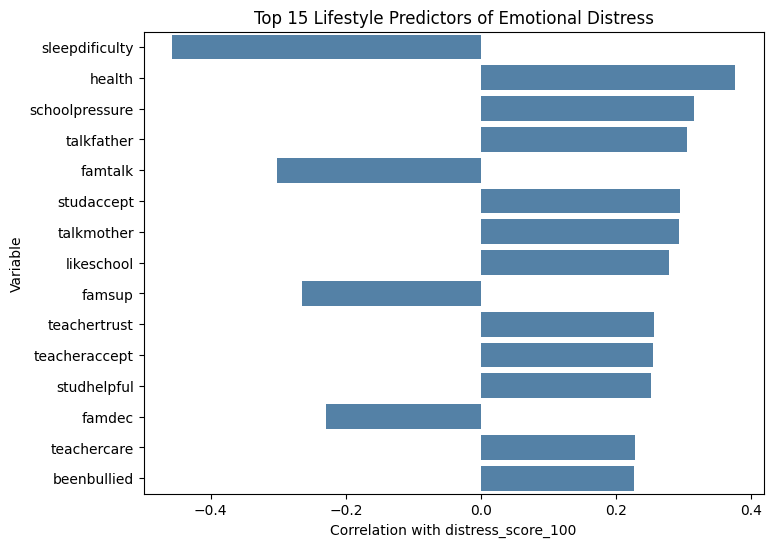

In [25]:
# Visualise strongest lifestyle predictors of distress
top15_model = corr_df_model.head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top15_model,
    x="correlation",
    y="variable",
    color="steelblue"
)

plt.title("Top 15 Lifestyle Predictors of Emotional Distress")
plt.xlabel("Correlation with distress_score_100")
plt.ylabel("Variable")

plt.show()

In [26]:
# Convert selected predictors to numeric
selected_x_vars = [
    "sleepdificulty",
    "health",
    "schoolpressure",
    "talkfather",
    "studaccept",
    "likeschool",
    "famtalk",
    "talkmother",
    "teachertrust",
    "teacheraccept",
    "studhelpful",
    "famsup",
    "teachercare",
    "beenbullied",
    "famdec"
]

for col in selected_x_vars:
    df_y[col] = pd.to_numeric(df_y[col], errors="coerce")

# Reverse the scales so that higher value = worse outcome, consistent with all the other variables
df_y["sleepdificulty_risk"] = 6 - df_y["sleepdificulty"]
df_y["famtalk_risk"] = 8 - df_y["famtalk"]
df_y["famsup_risk"] = 8 - df_y["famsup"]
df_y["famdec_risk"] = 8 - df_y["famdec"]

# Already risk-oriented variables, scale is correct direction
already_risk_vars = [
    "health",
    "schoolpressure",
    "studaccept",
    "likeschool",
    "teachertrust",
    "teacheraccept",
    "studhelpful",
    "teachercare",
    "beenbullied"
]

for col in already_risk_vars:
    df_y[col + "_risk"] = df_y[col]

# Special handling for talkfather / talkmother - treat 5 as a NA
for col in ["talkfather", "talkmother"]:
    temp = df_y[col].copy()
    temp = temp.replace(5, np.nan)   # 5 = don't have / don't see
    df_y[col + "_risk"] = temp

# Final processed list
final_x_risk_vars = [
    "sleepdificulty_risk",
    "health_risk",
    "schoolpressure_risk",
    "talkfather_risk",
    "studaccept_risk",
    "likeschool_risk",
    "famtalk_risk",
    "talkmother_risk",
    "teachertrust_risk",
    "teacheraccept_risk",
    "studhelpful_risk",
    "famsup_risk",
    "teachercare_risk",
    "beenbullied_risk",
    "famdec_risk"
]

/var/folders/6w/v4mx5hzn5z35dk5rqf7nc9nh0000gn/T/ipykernel_24590/2802491653.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_y["sleepdificulty_risk"] = 6 - df_y["sleepdificulty"]
/var/folders/6w/v4mx5hzn5z35dk5rqf7nc9nh0000gn/T/ipykernel_24590/2802491653.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_y["famtalk_risk"] = 8 - df_y["famtalk"]
/var/folders/6w/v4mx5hzn5z35dk5rqf7nc9nh0000gn/T/ipykernel_24590/2802491653.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

# Check that correlation of top 15 regressors are now all positive (after reversing some scales)

In [27]:
corr_results = []

for col in final_x_risk_vars:
    valid = df_y[[col, "distress_score_100"]].dropna()
    if len(valid) > 1000:
        corr = valid[col].corr(valid["distress_score_100"])
        corr_results.append({
            "variable": col,
            "correlation": corr,
            "abs_corr": abs(corr)
        })

corr_df_final = pd.DataFrame(corr_results).sort_values("abs_corr", ascending=False)
corr_df_final

,variable,correlation,abs_corr
0,sleepdificulty_risk,0.457509,0.457509
1,health_risk,0.376200,0.376200
3,talkfather_risk,0.336059,0.336059
2,schoolpressure_risk,0.314931,0.314931
7,talkmother_risk,0.312883,0.312883
6,famtalk_risk,0.301528,0.301528
4,studaccept_risk,0.294734,0.294734
5,likeschool_risk,0.278287,0.278287
11,famsup_risk,0.264729,0.264729
8,teachertrust_risk,0.255469,0.255469


# Drop rows with NA in any of the Y variables and X variables

In [28]:
X_vars = final_x_risk_vars
y_var = "distress_score_100"

model_df = df_y[X_vars + [y_var]].dropna()

print("Original rows:", len(df_y))
print("Rows after dropping NA:", len(model_df))

removed = len(df_y) - len(model_df)

print("Percent removed:", round(removed/len(df_y)*100,2), "%")

Original rows: 150867
Rows after dropping NA: 107027
Percent removed: 29.06 %


In [29]:
X = model_df[X_vars]
y = model_df[y_var]

# Split the train and test set

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 85621
Test rows: 21406


# Standardise the X variables since they have different scales

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LASSO CV to train the model and find the strongest contributors/most infuential predictors

In [32]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)

lasso.fit(X_train_scaled, y_train)

coef = pd.Series(lasso.coef_, index=X_vars)

selected_predictors = coef[coef != 0]

selected_predictors

sleepdificulty_risk    6.149398
health_risk            3.746234
schoolpressure_risk    3.239446
talkfather_risk        2.649915
studaccept_risk        1.365481
likeschool_risk        1.463861
famtalk_risk           1.481680
talkmother_risk        1.270486
teachertrust_risk      0.708451
teacheraccept_risk     0.588848
studhelpful_risk       0.883247
famsup_risk            0.651331
beenbullied_risk       1.694562
famdec_risk           -0.436179
dtype: float64

# Evaluate the fitted model on held-out test set

In [33]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = lasso.predict(X_test_scaled)

print("Test R²:", r2_score(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

Test R²: 0.41422241224997003
RMSE: 16.387656201248273


# Feature importance plot

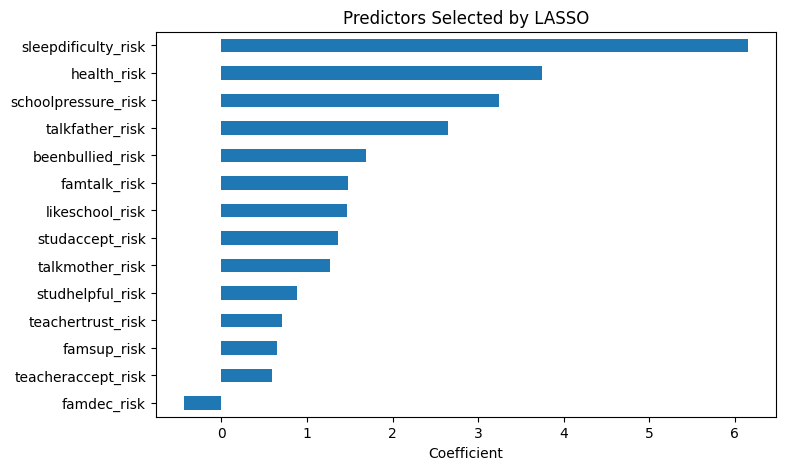

In [34]:
selected_predictors.sort_values().plot.barh(figsize=(8,5))

plt.title("Predictors Selected by LASSO")
plt.xlabel("Coefficient")

plt.show()

# Show samples of true distress score vs model predicted distress score

In [35]:
comparison = pd.DataFrame({
    "Actual_distress": y_test,
    "Predicted_distress": y_pred
})

comparison["Error"] = comparison["Predicted_distress"] - comparison["Actual_distress"]

comparison.sample(20)

,Actual_distress,Predicted_distress,Error
240597,26.868046,31.836452,4.968406
193244,7.472185,14.175532,6.703348
116659,60.530265,23.236039,-37.294226
61713,5.282045,18.470580,13.188535
63714,0.000000,8.176354,8.176354
185370,49.966174,29.041153,-20.925020
229348,14.147642,32.640422,18.492780
57279,5.282045,16.428141,11.146096
94393,35.360713,52.340419,16.979706
227000,19.395861,31.786481,12.390620


# Compare R^2 with std dev

In [36]:
df_y["distress_score_100"].std()

21.851740616542568